In [72]:
from scipy.stats import binom
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

In [40]:
binom_h0 = binom(n=30, p=0.5)
binom_h0.rvs(1) #возвращает какую-то одну реализацию случайной величины

array([16])

In [41]:
binom_h0.pmf(20)

np.float64(0.027981600724160654)

In [42]:
x_grid = np.arange(1, 31)
probs = binom_h0.pmf(x_grid)

## Односторонний критерий

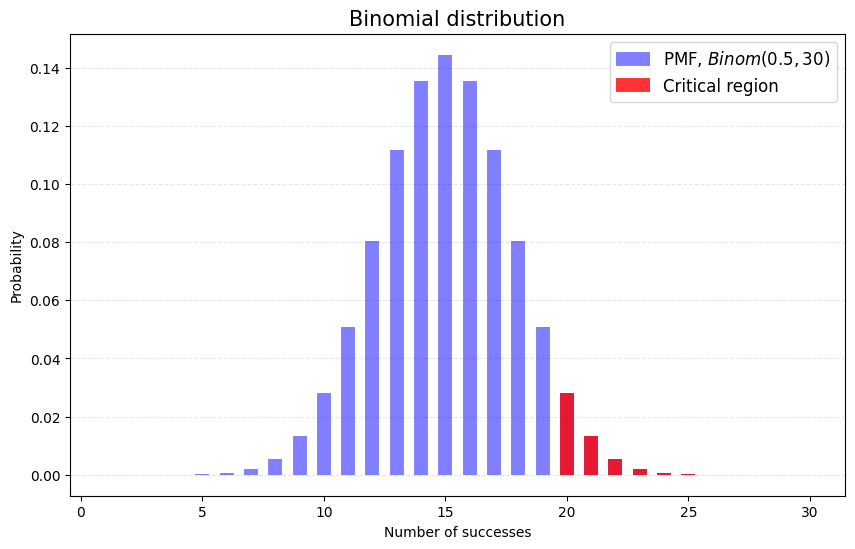

In [43]:
plt.figure(figsize=(10, 6)) 

plt.vlines(x_grid, 0, probs, linewidth=10.0, color='blue', alpha=0.5, label='PMF, $Binom(0.5, 30)$')

crit_reg = x_grid >= 20
plt.vlines(x_grid[crit_reg], 0, probs[crit_reg], linewidth=10.0, color='red', alpha=0.8, label='Critical region')

plt.title('Binomial distribution', fontsize=15)
plt.ylabel('Probability')
plt.xlabel('Number of successes')
plt.legend(fontsize=12) 
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [44]:
np.sum(probs[crit_reg])

np.float64(0.04936857335269451)

In [45]:
crit_reg = x_grid >= 19
np.sum(probs[crit_reg])

np.float64(0.10024421103298661)

In [46]:
binom_h0.cdf(19)

np.float64(0.9506314266473055)

In [47]:
1 - binom_h0.cdf(19)

np.float64(0.04936857335269451)

In [48]:
binom_h0.ppf(0.95)

np.float64(19.0)

In [49]:
def make_binom_criterion(n, mu=0.5, alpha=0.05):
    '''
    Вычисление критического значения для одностороннего теста (биномиальное распределение)
    ---------------------------------------------------------
    n - размер выборки
    mu - вероятность успеха при нулевой гипотезе
    alpha - допустимый уровень ошибки 1-ого рода
    
    '''

    binom_ho = binom(n, mu)
    q = binom_ho.ppf(1-alpha)
    return q +1

make_binom_criterion(30)

np.float64(20.0)

In [50]:
def pvalue_binom(n, mu, q):
    '''
    Вычисление p-value для одностороннего теста (биномиальное распределение)
    ---------------------------------------------------------
    n - размер выборки
    mu - вероятность успеха при нулевой гипотезе
    q - стастика, полученная в ходе эксперимента
    
    '''

    binom_h0 = binom(n, mu)
    return 1 - binom_h0.cdf(q -1)

pvalue_binom(30, 0.5, 19)

np.float64(0.10024421103298664)

## Двухсторонний критерий

In [51]:
binom_h0_nonsym =  binom(30, p=0.8)

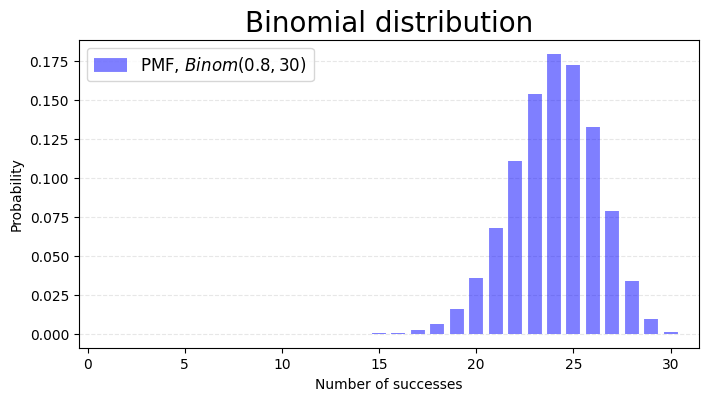

In [52]:
plt.figure(figsize=(8,4))

probs = binom_h0_nonsym.pmf(x_grid)
plt.vlines(x_grid, 0, probs, linewidth=10.0, color='blue', alpha=0.5, label='PMF, $Binom(0.8, 30)$')

plt.title('Binomial distribution', fontsize=20)
plt.ylabel('Probability')
plt.xlabel('Number of successes')
plt.legend(fontsize=12, loc='upper left') 
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [53]:
def two_sided_criterion_nonsym(n, mu, alpha):

    '''
    Вычисление критических значений для двухстороннего теста
    ---------------------------------------------------------
    n - размер выборки
    mu - вероятность успеха при нулевой гипотезе
    alpha - допустимый уровень ошибки 1-ого рода
    
    Возвращает два критических значения, таких что нулевая гипотеза отвергается, если
    (Q <= C1) or (Q >= C2)
    '''
    
    binom_h0 = binom(n, mu)

    c2 = binom_h0.ppf(1 - alpha/2) + 1
    c1 = binom_h0.ppf(alpha/2) - 1

    return c1, c2

In [54]:
c1, c2 = two_sided_criterion_nonsym(30, 0.8, 0.05)
c1,c2

(np.float64(18.0), np.float64(29.0))

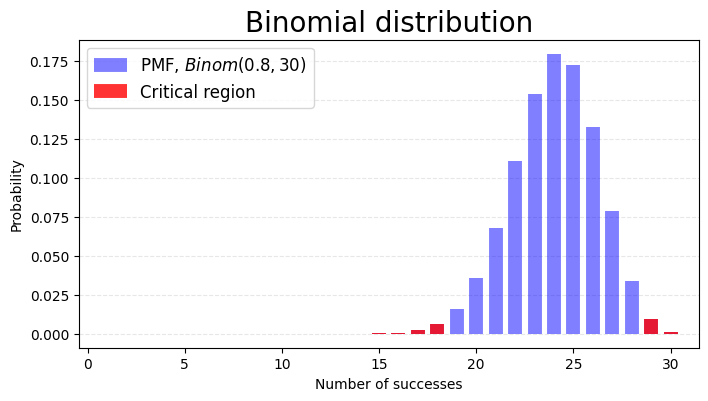

In [55]:
plt.figure(figsize=(8,4))

probs = binom_h0_nonsym.pmf(x_grid)
plt.vlines(x_grid, 0, probs, linewidth=10.0, color='blue', alpha=0.5, label='PMF, $Binom(0.8, 30)$')

crit_reg = (x_grid >= 29) | (x_grid <= 18)
plt.vlines(x_grid[crit_reg], 0, probs[crit_reg], linewidth=10.0, color='red', alpha=0.8, label='Critical region')

plt.title('Binomial distribution', fontsize=20)
plt.ylabel('Probability')
plt.xlabel('Number of successes')
plt.legend(fontsize=12, loc='upper left') 
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [56]:
def pvalue_two_sided(n, mu, q):

    '''
    Вычисление p-value для двухстороннего теста
    ---------------------------------------------------------

    n - размер выборки
    mu - вероятность успеха при нулевой гипотезе
    q - стастика, полученная в ходе эксперимента
    
    '''
     
    binom_h0 = binom(n, mu)

    pvalue_left = binom_h0.cdf(q)
    pvalue_right = 1 - binom_h0.cdf(q - 1)

    return 2 * min(pvalue_left, pvalue_right, 0.5)

In [57]:
pvalue_two_sided(30, 0.8, 28)

np.float64(0.08835797030399428)

## Мощность теста

In [58]:
def power_test(n, mu, mu_factual, alpha=0.05):

    '''
    Вычисление мощности теста для биномиального распределения
    ---------------------------------------------------------

    n - размер выборки
    mu - вероятность успеха при нулевой гипотезе
    mu_factual - вероятность успеха при альтернативной гипотезе 
    alpha - допустимый уровень ошибки 1-ого рода
    
    '''
    
    binom_h0 = binom(n, mu)
    binom_alt = binom(n, mu_factual)

    critical_value = binom_h0.ppf(1 - alpha) + 1

    return 1 - binom_alt.cdf(critical_value -1)

In [59]:
power_test(30, 0.5, 0.72, 0.05)

np.float64(0.8057093839291422)

In [60]:
def fpr_power_test(n, mu, mu_factual, q, alpha=0.05):

    '''
    Вычисление FPR и мощности теста для биномиального распределения
    ---------------------------------------------------------

    n - размер выборки
    mu - вероятность успеха при нулевой гипотезе
    mu_factual - вероятность успеха при альтернативной гипотезе 
    alpha - допустимый уровень ошибки 1-ого рода
    q - стастика, полученная в ходе эксперимента
    
    '''
    
    binom_h0 = binom(n, mu)
    binom_alt = binom(n, mu_factual)

    p_value = 1 - binom_h0.cdf(q - 1)
    critical_value = binom_h0.ppf(1 - alpha) + 1

    return p_value, 1 - binom_alt.cdf(critical_value -1)

In [61]:
fpr_power_test(30, 0.5, 0.6, 19)

(np.float64(0.10024421103298664), np.float64(0.2914718612234968))

In [62]:
n_grid = np.arange(10, 600, 10)
power = power_test(n=n_grid, mu=0.5, mu_factual=0.6)

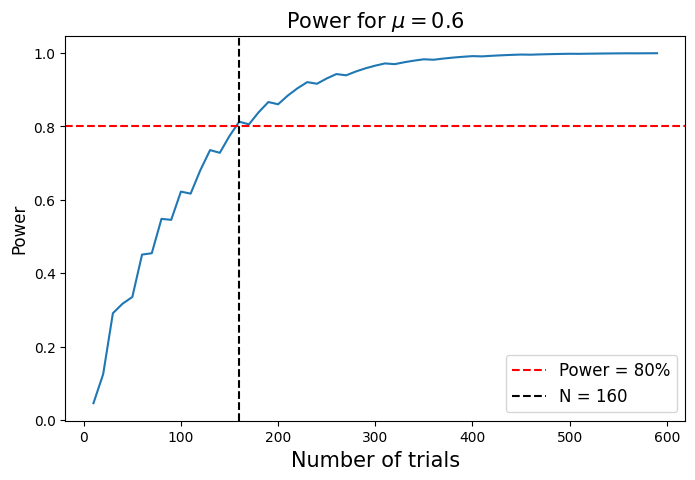

In [63]:
plt.figure(figsize=(8,5))
plt.title(f'Power for $\\mu = 0.6$', fontsize=15)
plt.xlabel('Number of trials', fontsize=15)
plt.ylabel('Power', fontsize=12)

plt.plot(n_grid, power)
plt.axhline(0.8, ls='--', color='red', label='Power = 80%')

min_n = n_grid[power >= 0.8].min()
plt.axvline(min_n, ls='--', color='black', label=f'N = {min_n}')
plt.legend(fontsize=12)
plt.show()

In [64]:
mu_grid = np.linspace(0.5, 1, 500)
power = power_test(n=30, mu=0.5, mu_factual=mu_grid)

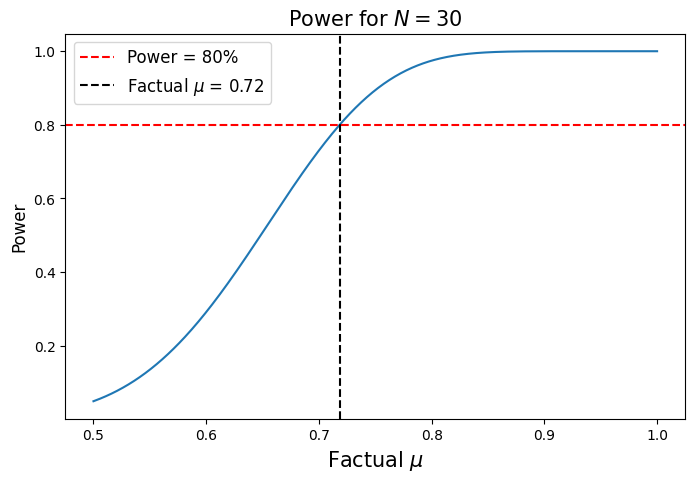

In [65]:
plt.figure(figsize=(8,5))
plt.title(f'Power for $N = 30$', fontsize=15)
plt.xlabel('Factual $\\mu$', fontsize=15)
plt.ylabel('Power', fontsize=12)

plt.plot(mu_grid, power)
plt.axhline(0.8, ls='--', color='red', label='Power = 80%')

min_mu = mu_grid[power >= 0.8].min()
plt.axvline(min_mu, ls='--', color='black', label=f'Factual $\\mu$ = {min_mu:.2f}')
plt.legend(fontsize=12)
plt.show()

## Minimal Detectable Effect (MDE)

In [66]:
def min_det_effect(n, mu, alpha=0.05):

    '''
    Вычисление минимального эффекта, который можно задетектировать с мощностью в как минимум 80%
    ---------------------------------------------------------

    n - размер выборки
    mu - вероятность успеха при нулевой гипотезе
    alpha - допустимый уровень ошибки 1-ого рода
    
    '''
    for mu_fact in np.linspace(0.5, 1, 500):
        if power_test(n, mu, mu_factual=mu_fact) >= 0.8:
            return mu_fact - mu

In [67]:
def min_det_effect(n, mu, alpha=0.05, min_power=0.8):

    '''
    Вычисление минимального эффекта, который можно задетектировать с мощностью в как минимум 80%
    ---------------------------------------------------------

    n - размер выборки
    mu - вероятность успеха при нулевой гипотезе
    alpha - допустимый уровень ошибки 1-ого рода
    min_power - минимальная мощность, которую  хотим достичь
    '''
    mu_fact = np.linspace(0, 1-mu, 500)
    power = power_test(n, mu, mu_factual=mu_fact + mu)
    effects = mu_fact[power >= min_power]
    return effects[0]
    

In [68]:
min_det_effect(30, 0.5, 19)

np.float64(0.21843687374749496)

## Доверительный интервал

In [69]:
success_cnt = 28
mu_grid = np.arange(0,1, 0.001)
mu_no_rejection = []

for mu_h0 in mu_grid:
    c1, c2 = two_sided_criterion_nonsym(30, mu=mu_h0, alpha=0.1)
    if (success_cnt > c1) and (success_cnt < c2):
        mu_no_rejection.append(mu_h0)

print(f'Condidence level: {min(mu_no_rejection)}--{max(mu_no_rejection)}')

Condidence level: 0.805--0.988


In [70]:
def confidence_interval(n, q, alpha=0.5):
    
    '''
    Вычисление границ доверительного интервала для двухстороннего теста
    ---------------------------------------------------------

    n - размер выборки
    alpha - допустимый уровень ошибки 1-ого рода
    q - статистика, полученная в ходе экспериментов

    Возвращает левую и правую границу интервала
    '''

    mu_grid = np.arange(0,1, 0.001)
    mu_no_rejection = []

    for mu_h0 in mu_grid:
        c1, c2 = two_sided_criterion_nonsym(n, mu=mu_h0, alpha=alpha)
        if (q > c1) and (q < c2):
            mu_no_rejection.append(mu_h0)

    return min(mu_no_rejection), max(mu_no_rejection)

In [73]:
n_experiments = 100
sample_size = 30
mu_factual = 0.5
binom_true = binom(sample_size, mu_factual)

confint_fail_cases = 0

for i in range(n_experiments):
    q = binom_true.rvs()
    L, R = confidence_interval(n=sample_size, q=q, alpha=0.1)
    if L <= mu_factual <= R:
        pass
    else:
        confint_fail_cases +=1

print(1 - confint_fail_cases/ n_experiments)
    

0.9


Теперь сделаем то же самое, но не перебором, а через встроенную функцию в библиотеке `statsmodel`.

In [76]:
n_experiments = 100
sample_size = 30
mu_factual = 0.5
binom_true = binom(sample_size, mu_factual)

confint_fail_cases = 0

for i in range(n_experiments):
    q = binom_true.rvs()
    L, R = proportion_confint(
        count=q,
        nobs = sample_size,
        alpha=0.1,
        method='wilson'
    )
    if L <= mu_factual <= R:
        pass
    else:
        confint_fail_cases +=1

print(1 - confint_fail_cases/ n_experiments)

0.9


Посмотрим, насколько успешен доверительный интервал Уилсона при различных размерах выборки. 

In [77]:
n_grid = np.arange(5, 100, 5)
int_success_rate = []

for n in n_grid:
    confint_fail_cases = 0
    for i in range(n_experiments):
        binom_true = binom(n, mu_factual)
        q = binom_true.rvs()
        L, R = proportion_confint(
            count=q,
            nobs = n,
            alpha=0.1,
            method='wilson'
        )
        if L <= mu_factual <= R:
            pass
        else:
            confint_fail_cases +=1
    int_success_rate.append(1 - confint_fail_cases/ n_experiments)

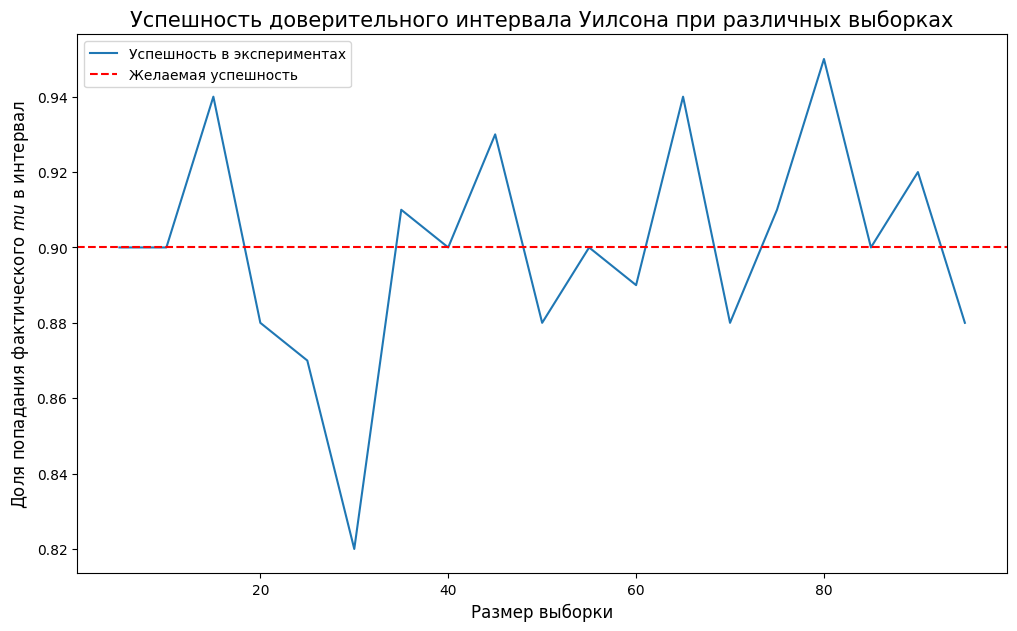

In [80]:
plt.figure(figsize=(12,7))
plt.title('Успешность доверительного интервала Уилсона при различных выборках' ,fontsize=15)
plt.xlabel('Размер выборки', fontsize=12)
plt.ylabel('Доля попадания фактического $mu$ в интервал', fontsize=12)

plt.plot(n_grid, int_success_rate, label='Успешность в экспериментах')
plt.axhline(0.9, ls='--', label='Желаемая успешность', color='red')

plt.legend()
plt.show()


Успешность будет колебаться вокруг заданного желаемого уровня успешности. Тест вычисляет границы с неточностью, но это позволяет посчитать их быстрее, чем обычным перебором. 